In [1]:
%pip install tqdm scipy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

## EDA

In [3]:
df = pd.read_csv("final_cleaned_data.csv", sep=';')
df['Date'] = pd.to_datetime(df['Date'])
audio_features = df.groupby('id')[['Danceability', 'Energy', 'Loudness_norm', 'Speechiness', 
                       'Acousticness', 'Instrumentalness', 'Valence']].first().reset_index()

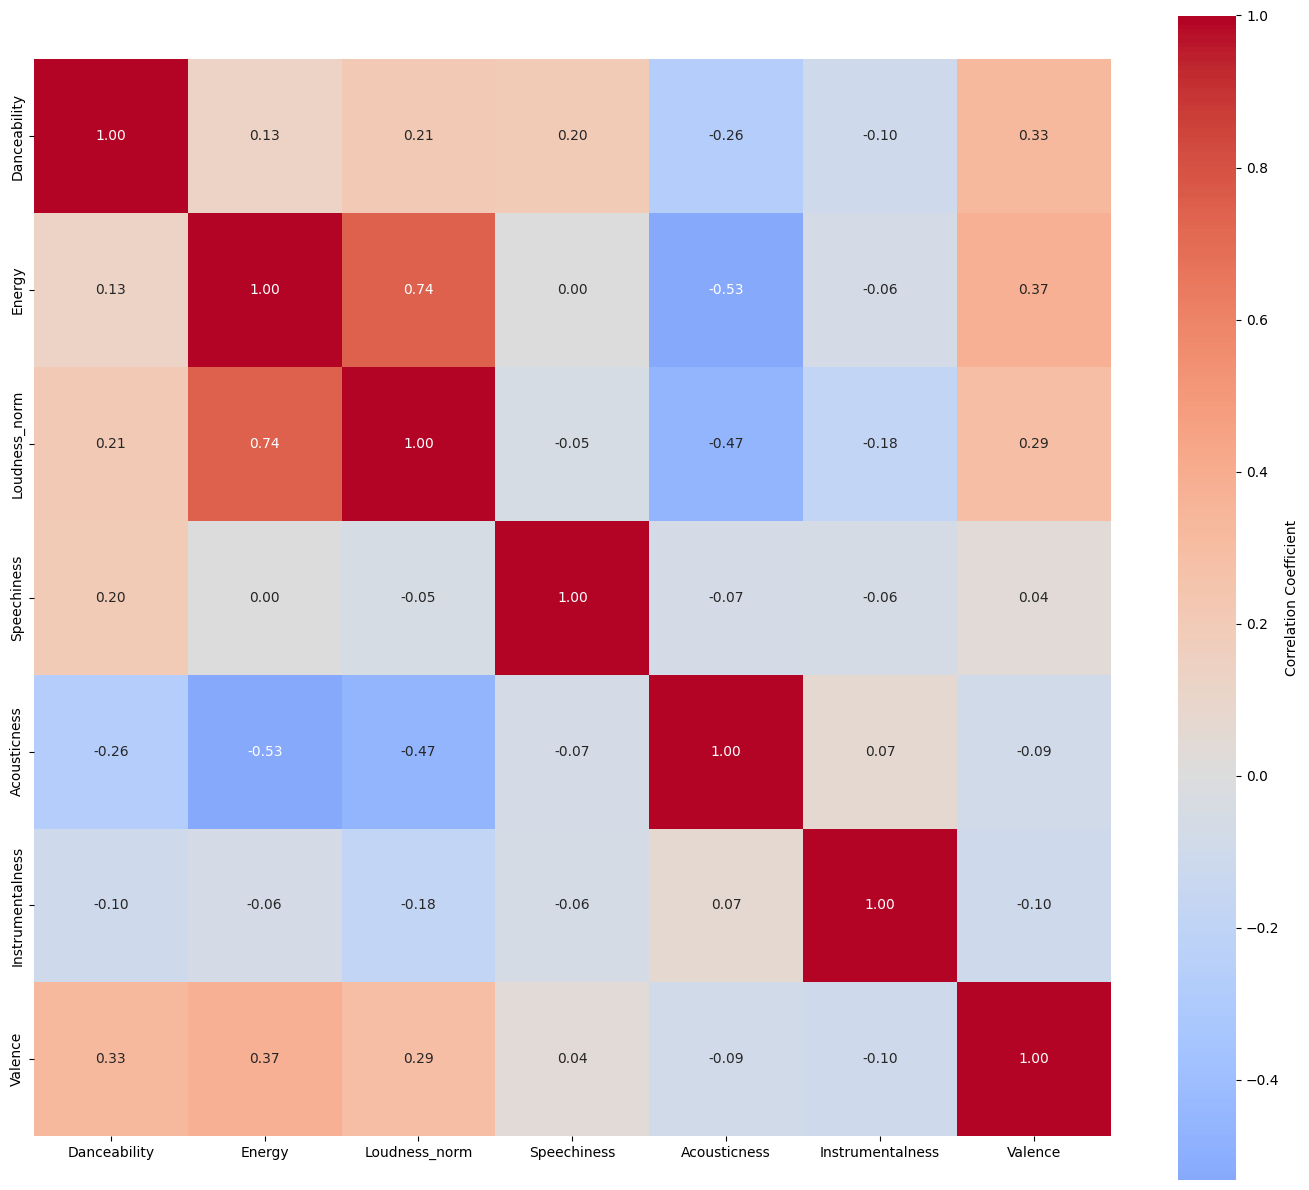

In [4]:
plt.figure(figsize=(14, 12))
sns.heatmap(audio_features.drop(columns=['id']).corr(),
            annot=True,
            cmap = 'coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'label': 'Correlation Coefficient'})
            
plt.tight_layout()
plt.show()



<Axes: xlabel='Valence', ylabel='Energy'>

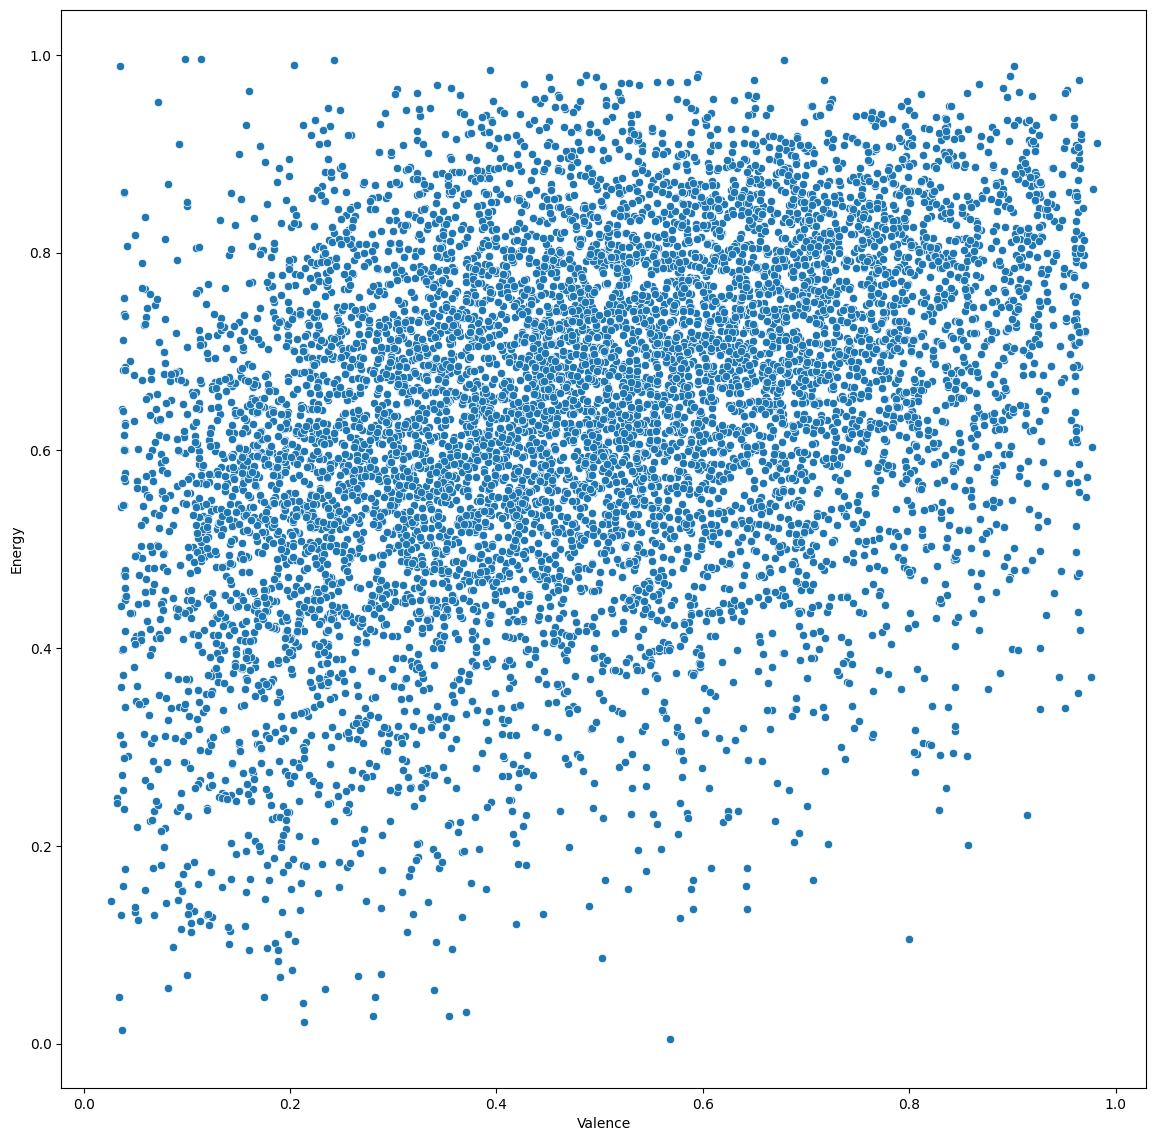

In [5]:
plt.figure(figsize=(14, 14))
sns.scatterplot(data=audio_features, x = 'Valence', y = 'Energy')


### Elbow Technique 

In [6]:
inertia_2_features = []
K = np.arange(1,11)
for k in K:
 kmeanModel = KMeans(n_clusters=k, n_init = 10, random_state = 42).fit(audio_features[['Energy', 'Valence']])
 inertia_2_features.append(kmeanModel.inertia_)

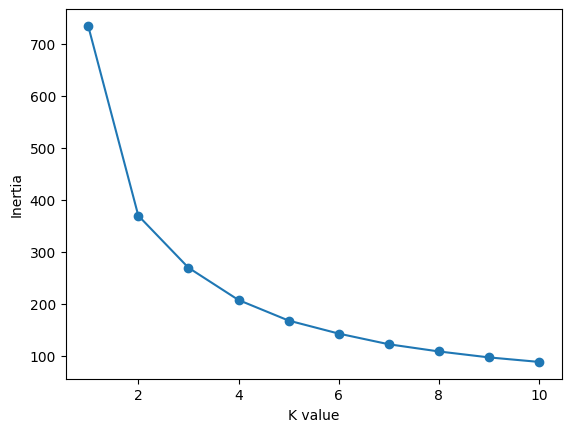

In [7]:
fig,ax = plt.subplots(1,1)
ax.plot(K, inertia_2_features, marker='o', linestyle='-')
ax.set_xlabel('K value')
ax.set_ylabel('Inertia')
plt.show()

We decide to choose k = 4
below is the plot for every cluster

In [8]:
k_means_4_2_feature = KMeans(n_clusters=4, n_init = 10 , random_state =42)
audio_features['cluster_4_2_feature'] = k_means_4_2_feature.fit_predict(audio_features[['Energy', 'Valence']])


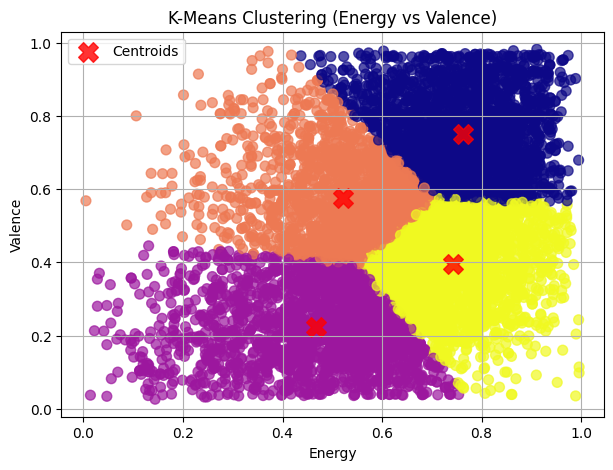

In [9]:
plt.figure(figsize=(7, 5))
plt.scatter(audio_features['Energy'], audio_features['Valence'],
            c=audio_features['cluster_4_2_feature'], cmap='plasma', s=50, alpha=0.7)
centers_4 = k_means_4_2_feature.cluster_centers_
plt.scatter(centers_4[:, 0], centers_4[:, 1], 
            c='red', s=200, alpha=0.8, marker='X', label='Centroids')

plt.title('K-Means Clustering (Energy vs Valence)')
plt.xlabel('Energy')
plt.ylabel('Valence')
plt.legend()
plt.grid(True)
plt.show()

Checking each center

In [10]:
for i, center in enumerate(centers_4):
    print(f"Cluster {i}: Center at Energy={center[0]:.4f} Valence={center[1]:.4f}")
    
print(audio_features['cluster_4_2_feature'].value_counts())

Cluster 0: Center at Energy=0.7633 Valence=0.7513
Cluster 1: Center at Energy=0.4663 Valence=0.2220
Cluster 2: Center at Energy=0.5211 Valence=0.5768
Cluster 3: Center at Energy=0.7428 Valence=0.3942
cluster_4_2_feature
3    2575
0    2500
1    2239
2    1847
Name: count, dtype: int64


We will map our cluster with Thayer's Model

In [11]:
class ThayerModel:
    def __init__(self):
        self.thayer_labels = {
            0: "Excited/Happy (High Energy + Positive Valence)",
            1: "Angry/Anxious (High Energy + Negative Valence)", 
            2: "Sad/Depressed (Low Energy + Negative Valence)",
            3: "Calm/Content (Low Energy + Positive Valence)"
        }
    def label_cluster(self, data, kmeans_labels):
        energy_threshold = np.mean(data.iloc[:,0])
        valence_threshold = np.mean(data.iloc[:,1])
        
        unique_cluster_id = np.unique(kmeans_labels)
        centroids = {}
        cluster_stats = {}
        
        for id in unique_cluster_id:
            cluster_id_mask = kmeans_labels == id
            cluster_points = data[cluster_id_mask]
            centroids[id] = np.mean(cluster_points, axis = 0)
            
            cluster_stats[id] = {
                'n_points': len(cluster_points),
                'centroid': centroids[id],
                'points': cluster_points
            }
        
        thayer_model = {}
        
        for id, (energy, valence) in centroids.items():
            if energy >= energy_threshold and valence >= valence_threshold:
                quadrant = 0  # Excited/Happy
            elif energy >= energy_threshold and valence < valence_threshold:
                quadrant = 1  # Angry/Anxious
            elif energy < energy_threshold and valence < valence_threshold:
                quadrant = 2  # Sad/Depressed
            else:  # energy < threshold and valence >= threshold
                quadrant = 3  # Calm/Content
            thayer_model[id] = quadrant
        
        for id, quadrant in thayer_model.items():
            energy, valence = centroids[id]
            print(f"K-means Cluster {id} equal to Thayer {self.thayer_labels[quadrant]}")
            print(f"  Centroid: Energy={energy:.3f}, Valence={valence:.3f}")
        
        return {
            'centroids': centroids,
            'thayer_assignments': thayer_model,
            'energy_threshold': energy_threshold,
            'valence_threshold': valence_threshold,
            'cluster_stats': cluster_stats
        }
            
        

In [12]:
thayer_model = ThayerModel()
results = thayer_model.label_cluster(audio_features[['Energy', 'Valence']], audio_features['cluster_4_2_feature'])


for id, cluster_stat in results['cluster_stats'].items():
    print(cluster_stat['centroid'])
    print(f"\n{thayer_model.thayer_labels[id]}: {cluster_stat['n_points']} points")



K-means Cluster 0 equal to Thayer Excited/Happy (High Energy + Positive Valence)
  Centroid: Energy=0.763, Valence=0.751
K-means Cluster 1 equal to Thayer Sad/Depressed (Low Energy + Negative Valence)
  Centroid: Energy=0.467, Valence=0.222
K-means Cluster 2 equal to Thayer Calm/Content (Low Energy + Positive Valence)
  Centroid: Energy=0.520, Valence=0.577
K-means Cluster 3 equal to Thayer Angry/Anxious (High Energy + Negative Valence)
  Centroid: Energy=0.743, Valence=0.395
Energy     0.763285
Valence    0.751126
dtype: float64

Excited/Happy (High Energy + Positive Valence): 2500 points
Energy     0.466696
Valence    0.221967
dtype: float64

Angry/Anxious (High Energy + Negative Valence): 2239 points
Energy     0.520427
Valence    0.577029
dtype: float64

Sad/Depressed (Low Energy + Negative Valence): 1847 points
Energy     0.742804
Valence    0.394539
dtype: float64

Calm/Content (Low Energy + Positive Valence): 2575 points


Plot the model based on the Thaymodel Label 

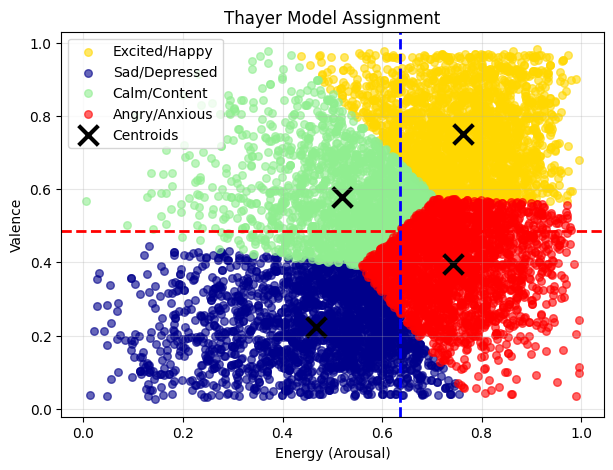

In [13]:
plt.figure(figsize=(7, 5))
thayer_colors = ['gold', 'red', 'darkblue', 'lightgreen']
thayer_names = ['Excited/Happy', 'Angry/Anxious', 'Sad/Depressed', 'Calm/Content']
centroid_array = np.array(list(results['centroids'].values()))
for id, quadrant in results['thayer_assignments'].items():
    mask = audio_features['cluster_4_2_feature'] == id
    plt.scatter(audio_features.loc[mask, 'Energy'], audio_features.loc[mask, 'Valence'], c=thayer_colors[quadrant], alpha=0.6, label=thayer_names[quadrant], s=30)
        
plt.scatter(centroid_array[:,0], centroid_array[:, 1], c='black', 
                marker='x', s=200, linewidths=3, label='Centroids')
plt.axhline(y=results['valence_threshold'], color='red', linestyle='--', linewidth=2)
plt.axvline(x=results['energy_threshold'], color='blue', linestyle='--', linewidth=2)
    
plt.xlabel('Energy (Arousal)')
plt.ylabel('Valence')
plt.title('Thayer Model Assignment')
plt.legend()
plt.grid(True, alpha=0.3)

Check what kind of song in this cluster

In [14]:
target_ids = audio_features[audio_features['cluster_4_2_feature'] == 3]['id']

mask = df['id'].isin(target_ids)

filtered_df = df[mask]

In [15]:
pd.reset_option('display.max_rows',100)

In [16]:
pd.set_option('display.max_rows', 200)

filtered_df['Title'].head(200)

1                                    WHERE SHE GOES
4                                         un x100to
7                                         Kill Bill
16                                  Angels Like You
17                                       Last Night
27                                     Cruel Summer
28                                  I'm Good (Blue)
30                                   Hits Different
34                                           Tattoo
38                                       Like Crazy
40                                           Yellow
43                                      Blank Space
44                                          Hey Mor
45                                           Frágil
47                                      Coco Chanel
48                                  Blinding Lights
49                                     Viva La Vida
50                                      Mockingbird
52                               Baby Don't Hurt Me
54          

### Subplot

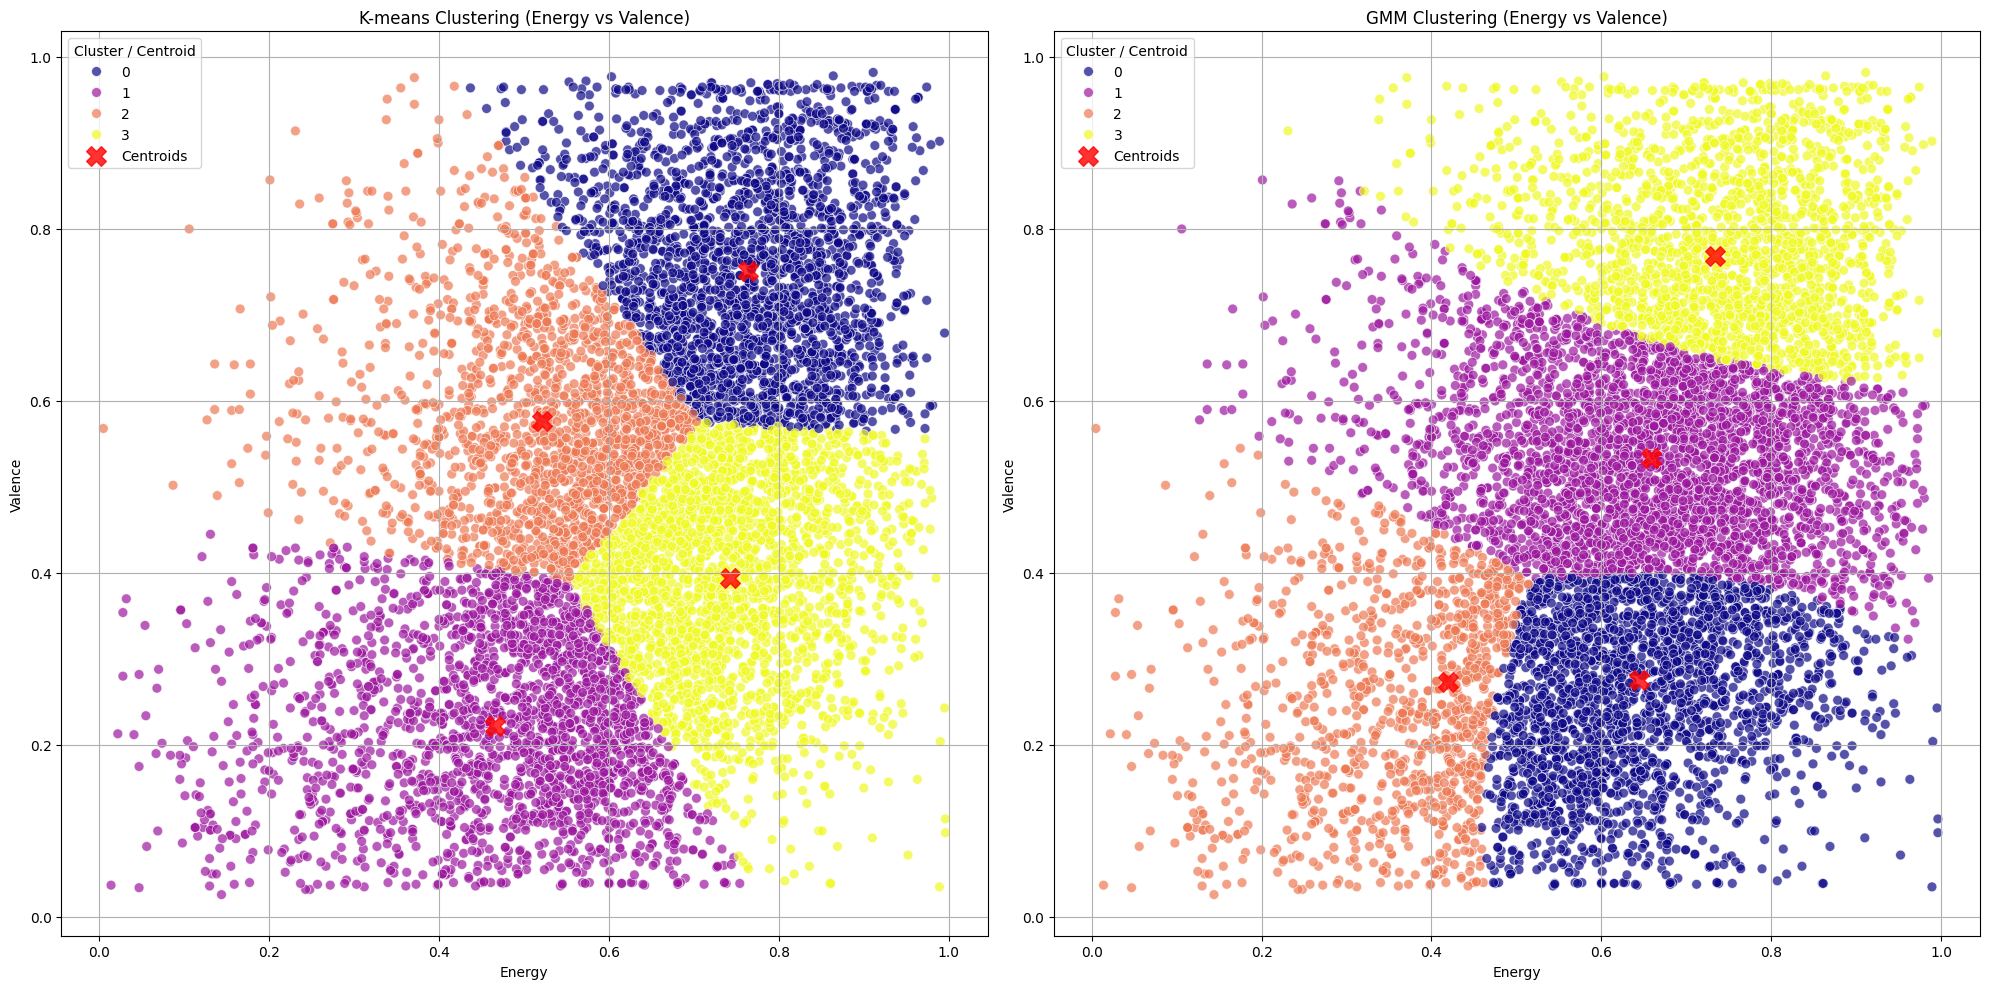

In [17]:
models = {
        'K-means': KMeans(n_clusters=4, n_init = 10,random_state=42),
        'GMM': GaussianMixture(n_components=4, random_state=42),
}
fig, axes = plt.subplots(1, len(models), figsize=(20, 10))

for i, (name, model) in enumerate(models.items()):
        labels = model.fit_predict(audio_features[['Energy', 'Valence']])
        sns.scatterplot(audio_features, x = 'Energy', y = 'Valence', 
                        ax = axes[i], hue = labels, 
                        palette= 'plasma',    
                        s=50,
                        alpha=0.7)
        axes[i].set_title(f'{name} Clustering (Energy vs Valence)')
        axes[i].set_xlabel('Energy')
        axes[i].set_ylabel('Valence')
        axes[i].legend(title='Cluster')
        axes[i].grid(True)
        if name == 'K-means':
                centers_4 = model.cluster_centers_
                axes[i].scatter(
                centers_4[:, 0], centers_4[:, 1],
                c='red', s=200, alpha=0.8, marker='X', label='Centroids'
                )
                axes[i].legend(title='Cluster / Centroid')
        elif name == 'GMM':
                centroids_gmm = model.means_
                axes[i].scatter(
                centroids_gmm[:, 0], centroids_gmm[:, 1],
                c='red', s=200, alpha=0.8, marker='X', label='Centroids'
                )
                axes[i].legend(title='Cluster / Centroid')
        
        
plt.tight_layout()
plt.show()


Model Evaluation

metrics

In [18]:
models = {
        'K-means': KMeans(n_clusters=4, n_init = 10,random_state=42),
        'GMM': GaussianMixture(n_components=4, random_state=42),
}
results = {}
data = audio_features[['Energy','Valence']]
for i, (name, model) in enumerate(models.items()):
    labels = model.fit_predict(data)
    silhouette = silhouette_score(data,labels)
    calinski = calinski_harabasz_score(data, labels)
    davies = davies_bouldin_score(data,labels)
    results[name] = {
            'silhouette' :  silhouette,
            'calinski': calinski,
            'davies': davies
    }

results

    

{'K-means': {'silhouette': 0.35841423329656485,
  'calinski': 7753.898639230809,
  'davies': 0.8881275193079379},
 'GMM': {'silhouette': 0.3157591820457839,
  'calinski': 6877.331446504464,
  'davies': 1.0062373366171518}}

Now we test hypothesis

In [19]:

kmeans_metrics = {
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

best_inertia = float('inf')
best_kmeans = None
for i in tqdm(range(50)):
            kmeans = KMeans(n_clusters=4, random_state=i, n_init=10)
            labels = kmeans.fit_predict(data)
            
            sil = silhouette_score(data, labels)
            db = davies_bouldin_score(data, labels)
            ch = calinski_harabasz_score(data, labels)
            
            kmeans_metrics['silhouette'].append(sil)
            kmeans_metrics['davies_bouldin'].append(db)
            kmeans_metrics['calinski_harabasz'].append(ch)
            
            if kmeans.inertia_ < best_inertia:
                best_inertia = kmeans.inertia_
                best_kmeans = kmeans
        
print(f"best k-means inertia: {best_inertia:.2f}")


100%|██████████| 50/50 [00:25<00:00,  1.96it/s]

best k-means inertia: 207.60


Run GMM

In [20]:
gmm_metrics = {
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

best_bic = float('inf')
best_gmm = None
for i in tqdm(range(50)):
            gmm = GaussianMixture(n_components=4, random_state=i, n_init=10)
            labels = gmm.fit_predict(data)
            
            sil = silhouette_score(data, labels)
            db = davies_bouldin_score(data, labels)
            ch = calinski_harabasz_score(data, labels)
            
            gmm_metrics['silhouette'].append(sil)
            gmm_metrics['davies_bouldin'].append(db)
            gmm_metrics['calinski_harabasz'].append(ch)
            
            if gmm.bic(data) < best_bic:
                best_bic = gmm.bic(data)
                best_gmm = gmm
        
print(f"best k-means inertia: {best_inertia:.2f}")

100%|██████████| 50/50 [00:33<00:00,  1.48it/s]

best k-means inertia: 207.60


Find Statistic Test

In [21]:
metrics = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
alpha = 0.05
statistical_results = {}
for metric in metrics:
    kmeans_vals = np.array(kmeans_metrics[metric])
    gmm_vals = np.array(gmm_metrics[metric])
    t_stat, p_value = stats.ttest_rel(kmeans_vals, gmm_vals)
    test_type = "paired t-test"
    if len(kmeans_vals) == len(gmm_vals):
        diff = kmeans_vals - gmm_vals
        ci_lower, ci_upper = stats.t.interval(1-alpha, len(diff)-1, 
                                                     loc=diff.mean(), scale=stats.sem(diff))
            
    statistical_results[metric] = {
                'kmeans_mean': kmeans_vals.mean(),
                'gmm_mean': gmm_vals.mean(),
                'kmeans_std': kmeans_vals.std(),
                'gmm_std': gmm_vals.std(),
                't_statistic': t_stat,
                'p_value': p_value,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'test_type': test_type
            }
    print(f"{test_type}: t={t_stat:.4f}, p={p_value:.6f}")

    print(f"95% CI for difference: [{ci_lower:.4f}, {ci_upper:.4f}]")
                
    if p_value < alpha:
        print(f"sig at α={alpha}")
        print(f"metric: {metric}")
        print(f"k-mean: {kmeans_vals.mean()}")
        print(f"gmm: {gmm_vals.mean()}")
        if metric == 'silhouette' or  metric == 'calinski_harabasz' :
            if kmeans_vals.mean() > gmm_vals.mean():
                print(f"kmm")
            else:
                print(f"gmm")
        else:
            if kmeans_vals.mean() < gmm_vals.mean():
                print(f"k-means")
            else:
                print(f"gmm")
    else:
        print(f"not sig at α={alpha}")

paired t-test: t=103.9383, p=0.000000
95% CI for difference: [0.0069, 0.0071]
sig at α=0.05
metric: silhouette
k-mean: 0.35873155797759554
gmm: 0.35173281175761817
kmm
paired t-test: t=-53.2990, p=0.000000
95% CI for difference: [-0.0123, -0.0114]
sig at α=0.05
metric: davies_bouldin
k-mean: 0.8865843185559491
gmm: 0.898389689251887
k-means
paired t-test: t=236.7438, p=0.000000
95% CI for difference: [498.9389, 507.4818]
sig at α=0.05
metric: calinski_harabasz
k-mean: 7753.915426136147
gmm: 7250.705085092515
kmm


In [22]:
n_bootstrap=1000
kmeans_bootstrap = []
gmm_bootstrap = []

n_samples = len(data)

for i in range(n_bootstrap):
    if i % 100 == 0:
        print(f"  Bootstrap iteration {i+1}/{n_bootstrap}")
    
    indices = np.random.choice(n_samples, n_samples, replace=True)
    bootstrap_data = data.iloc[indices].values
    
    kmeans = KMeans(n_clusters=4, random_state=i, n_init=5)
    kmeans_labels = kmeans.fit_predict(bootstrap_data)
    kmeans_sil = silhouette_score(bootstrap_data, kmeans_labels)
    kmeans_bootstrap.append(kmeans_sil)
    
    gmm = GaussianMixture(n_components=4, random_state=i, max_iter=100)
    gmm_labels = gmm.fit_predict(bootstrap_data)
    gmm_sil = silhouette_score(bootstrap_data, gmm_labels)
    gmm_bootstrap.append(gmm_sil)

kmeans_bootstrap = np.array(kmeans_bootstrap)
gmm_bootstrap = np.array(gmm_bootstrap)

diff_bootstrap = kmeans_bootstrap - gmm_bootstrap
bootstrap_mean = diff_bootstrap.mean()
bootstrap_std = diff_bootstrap.std()

ci_lower, ci_upper = np.percentile(diff_bootstrap, [2.5, 97.5])

p_value = np.mean(np.abs(diff_bootstrap) >= np.abs(bootstrap_mean))

print(f"bootstrap results (Silhouette Score):")
print(f"mean difference (K-means - GMM): {bootstrap_mean:.6f}")
print(f"std of difference: {bootstrap_std:.6f}")
print(f"95% CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
print(f"bootstrap p-value: {p_value:.6f}")

if p_value < alpha:
    print(f"sig at α={alpha}")
    if bootstrap_mean > 0:
        print(f"kmean")
    else:
        print(f"gmm")
else:
    print(f"not sig at α={alpha}")

bootstrap_results = {
    'bootstrap_diff': diff_bootstrap,
    'bootstrap_mean': bootstrap_mean,
    'bootstrap_std': bootstrap_std,
    'ci_lower': ci_lower,
    'ci_upper': ci_upper,
    'p_value': p_value
}



  Bootstrap iteration 1/1000
  Bootstrap iteration 101/1000
  Bootstrap iteration 201/1000
  Bootstrap iteration 301/1000
  Bootstrap iteration 401/1000
  Bootstrap iteration 501/1000
  Bootstrap iteration 601/1000
  Bootstrap iteration 701/1000
  Bootstrap iteration 801/1000
  Bootstrap iteration 901/1000
bootstrap results (Silhouette Score):
mean difference (K-means - GMM): 0.013999
std of difference: 0.012508
95% CI: [0.002415, 0.043817]
bootstrap p-value: 0.233000
not sig at α=0.05


In [23]:
significant_metrics = 0
kmeans_wins = 0
gmm_wins = 0

for metric, results in statistical_results.items():
    if results['p_value'] < alpha:
        significant_metrics += 1
        if results['kmeans_mean'] > results['gmm_mean']:
            kmeans_wins += 1
        else:
            gmm_wins += 1

print(f"statistical tests summary:")
print(f"significant differences: {significant_metrics}/3 metrics")
print(f"k-means wins: {kmeans_wins}")
print(f"gmm wins: {gmm_wins}")

print(f"\nBootstrap test (silhouette):")
if bootstrap_results['p_value'] < alpha:
    if bootstrap_results['bootstrap_mean'] > 0:
        print("k-means significantly better")
    else:
        print("gmm significantly better")
else:
    print("no significant difference")

print("recommendation")

if significant_metrics >= 2 and kmeans_wins >= 2:
    print("k-means")
elif significant_metrics >= 2 and gmm_wins >= 2:
    print("gmm")
elif bootstrap_results['p_value'] < self.alpha:
    if bootstrap_results['bootstrap_mean'] > 0:
        print("bootstrap test favors K-means")
    else:
        print("gmm")



statistical tests summary:
significant differences: 3/3 metrics
k-means wins: 2
gmm wins: 1

Bootstrap test (silhouette):
no significant difference
recommendation
k-means
